# Nexons — ALS / *UNC13A* cryptic-exon worked example

This notebook runs the whole worked example described in `README_dev.md`:

1. builds three **synthetic** long-read datasets in `data/input/example1|2|3/`,
2. runs `nexons.py` on each, writing figures and summary tables to `data/output/`,
3. reads the transcript- and gene-level count tables back, and
4. shows the point of the exercise — **a cryptic-exon isoform switch that is
   obvious at the transcript level and invisible at the gene level.**

### Before you start

This notebook must run on the **`Python (nexons pixi)`** kernel (top right).
If that kernel is not offered, launch JupyterLab from inside the pixi
environment so it can see the kernel that ships with it:

```bash
cd sandbox
pixi run jupyter lab
```

> **Synthetic data.** Every read and every coordinate below is generated by
> `make_dummy_data.py`. No patient, cell-line or public sequencing data is
> involved, and no coordinate is a real genome coordinate. Nothing here is for
> clinical or diagnostic use.

## 0. Check the kernel

In [2]:
import sys, subprocess, json, shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pysam

In [3]:
# Locate sandbox/ regardless of whether this notebook is opened from
# sandbox/notebooks/ (normal) or from sandbox/ itself.
here = Path.cwd()
SANDBOX = next((p for p in (here, *here.parents)
                if (p / "data" / "make_dummy_data.py").exists()), None)
assert SANDBOX is not None, (
    f"Could not locate sandbox/ from {here}. Open this notebook from "
    "sandbox/notebooks/ after launching `pixi run jupyter lab` in sandbox/."
)

DATA        = SANDBOX / "data"
DATA_INPUT  = DATA / "input"    # dummy datasets built by make_dummy_data.py
DATA_OUTPUT = DATA / "output"   # figures + summary tables made by this notebook
DATA_OUTPUT.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DATA))   # so `import make_dummy_data` works
NEXONS = SANDBOX.parent / "nexons.py"

print("sandbox     :", SANDBOX)
print("input dir   :", DATA_INPUT)
print("output dir  :", DATA_OUTPUT)
print("interpreter :", sys.executable)
print("in pixi env :", ".pixi/envs" in sys.executable)
print("pysam       :", pysam.__version__)
print("pandas      :", pd.__version__)
print("nexons.py   :", NEXONS, "found" if NEXONS.exists() else "MISSING")

/home/ubuntu/nexons/sandbox
interpreter : /home/ubuntu/nexons/sandbox/.pixi/envs/default/bin/python
in pixi env : True
pysam       : 0.24.0
pandas      : 3.0.5
nexons.py   : /home/ubuntu/nexons/nexons.py found


## 1. The toy locus

Real *UNC13A* has 40-odd exons. The toy model keeps a 21-exon simplification
and inserts **one cryptic exon into the intron between exon 20 and exon 21** —
the intron in which TDP-43 loss of function de-represses cryptic splicing in
ALS/FTD. Two transcripts are annotated:

| transcript | structure | biology it stands for |
|---|---|---|
| `UNC13A_TOY-CANONICAL` | exons 1–21 | TDP-43 present, cryptic exon repressed |
| `UNC13A_TOY-CRYPTIC` | exons 1–20 + **CE** + exon 21 | TDP-43 depleted, cryptic exon included |

Because the two transcripts differ by a single internal exon, a read can only
be assigned to one of them if it actually **spans that region** — which is
exactly what a long read does and a short read does not.

In [4]:
import make_dummy_data as toy

print("contig      :", toy.CHROM, f"({toy.CHROM_LENGTH:,} bp)")
print("gene span   :", toy.GENE_START, "-", toy.GENE_END, "(+ strand)")
print("exon 20     :", toy.exon(20))
print("cryptic exon:", toy.CRYPTIC_EXON, "  <- inside intron 20/21")
print("exon 21     :", toy.exon(21))
print()
print("canonical   :", len(toy.CANONICAL_EXONS), "exons")
print("cryptic     :", len(toy.CRYPTIC_EXONS), "exons")

contig      : UNC13A_TOY_chr (40,000 bp)
gene span   : 10000 - 30149 (+ strand)
exon 20     : (29000, 29149)
cryptic exon: (29500, 29649)   <- inside intron 20/21
exon 21     : (30000, 30149)

canonical   : 21 exons
cryptic     : 22 exons


## 2. Build the three example datasets

Each example directory holds one GTF and three BAMs. The three BAMs are the
ALS contrast — the fraction of transcript-assignable reads that carry the
cryptic exon is the only thing that differs between them:

| BAM | cryptic fraction | stands for |
|---|---|---|
| `control.bam` | 0.05 | TDP-43 nuclear-functional |
| `tdp43_depleted.bam` | 0.65 | TDP-43 loss of function |
| `mixed.bam` | 0.35 | mixed / intermediate population |

The three **examples** share that biology but differ in read population, so
each produces a visibly different QC report:

| example | GTF | read population | QC signature |
|---|---|---|---|
| `example1` | one gene | mostly transcript-assignable, all sense-strand | reference behaviour |
| `example2` | **+ overlapping paralog** | mostly short internal fragments | ~50 % **purple** "Multi Gene Match" |
| `example3` | one gene | 1/3 of reads antisense | ~1/3 **blue** "Opposite Strand Alignment" |

In [5]:
for ex in (1, 2, 3):
    d = toy.build_example(ex, DATA_INPUT)
    bams = sorted(p.name for p in d.glob("*.bam"))
    print(f"{d.name}: {', '.join(bams)}  +  {(d / 'unc13a_toy.gtf').name}")

example1: control.bam, mixed.bam, tdp43_depleted.bam  +  unc13a_toy.gtf
example2: control.bam, mixed.bam, tdp43_depleted.bam  +  unc13a_toy.gtf
example3: control.bam, mixed.bam, tdp43_depleted.bam  +  unc13a_toy.gtf


## 3. Run nexons

The command is the one documented in `README_dev.md`:

```bash
python ../../nexons.py --maxtsl 0 --outbase results/nexons_output \
    unc13a_toy.gtf control.bam tdp43_depleted.bam mixed.bam
```

`--maxtsl 0` switches off the transcript-support-level filter, which a
synthetic annotation cannot meaningfully populate. Everything else is left at
the nexons defaults (`--flex 10` for internal splice sites, `--endflex 500`
for transcript ends, `--direction none`).

In [6]:
SAMPLES = ["control.bam", "tdp43_depleted.bam", "mixed.bam"]

def run_nexons(example: int) -> Path:
    d = DATA_INPUT / f"example{example}"
    (d / "results").mkdir(exist_ok=True)
    cmd = [sys.executable, str(NEXONS), "--maxtsl", "0",
           "--outbase", "results/nexons_output", "unc13a_toy.gtf", *SAMPLES]
    r = subprocess.run(cmd, cwd=d, capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(f"nexons failed on example{example}:\n{r.stderr[-3000:]}")
    return d / "results"

RESULTS = {ex: run_nexons(ex) for ex in (1, 2, 3)}
for ex, r in RESULTS.items():
    print(f"example{ex} ->", ", ".join(sorted(p.name for p in r.iterdir())))

example1 -> cryptic_exon_switch.png, nexons_output_control_qc.html, nexons_output_control_stats.txt, nexons_output_gene.txt, nexons_output_mixed_qc.html, nexons_output_mixed_stats.txt, nexons_output_partial.txt, nexons_output_tdp43_depleted_qc.html, nexons_output_tdp43_depleted_stats.txt, nexons_output_unique.txt
example2 -> nexons_output_control_qc.html, nexons_output_control_stats.txt, nexons_output_gene.txt, nexons_output_mixed_qc.html, nexons_output_mixed_stats.txt, nexons_output_partial.txt, nexons_output_tdp43_depleted_qc.html, nexons_output_tdp43_depleted_stats.txt, nexons_output_unique.txt
example3 -> nexons_output_control_qc.html, nexons_output_control_stats.txt, nexons_output_gene.txt, nexons_output_mixed_qc.html, nexons_output_mixed_stats.txt, nexons_output_partial.txt, nexons_output_tdp43_depleted_qc.html, nexons_output_tdp43_depleted_stats.txt, nexons_output_unique.txt


## 4. The three count tables

- **`_unique.txt`** — reads whose exon structure matches *one whole
  transcript*. This is the isoform-resolved table and the one that answers the
  biological question.
- **`_partial.txt`** — reads that match one transcript unambiguously but do not
  run its full length (truncated reads). Note that nexons counts a full match
  here as well, so `partial >= unique` by construction.
- **`_gene.txt`** — reads that resolve to the gene but not to a single
  transcript (fragments compatible with both isoforms, intron-retaining reads).

In [7]:
def load(results: Path, level: str) -> pd.DataFrame:
    return pd.read_csv(results / f"nexons_output_{level}.txt", sep="\t")

unique1 = load(RESULTS[1], "unique")
gene1 = load(RESULTS[1], "gene")

print("--- transcript level (unique) ---")
print(unique1[["Transcript_ID", *SAMPLES]].to_string(index=False))
print("\n--- gene level ---")
print(gene1[["Gene_ID", *SAMPLES]].to_string(index=False))

--- transcript level (unique) ---
       Transcript_ID  control.bam  tdp43_depleted.bam  mixed.bam
UNC13A_TOY-CANONICAL          437                 161        299
  UNC13A_TOY-CRYPTIC           23                 299        161

--- gene level ---
   Gene_ID  control.bam  tdp43_depleted.bam  mixed.bam
UNC13A_TOY          870                 870        870


### Cryptic-exon inclusion

The standard readout for a cryptic exon is the fraction of the gene's
assignable transcripts that include it:

$$\mathrm{inclusion} = \frac{\text{cryptic}}{\text{cryptic} + \text{canonical}}$$

In [8]:
def inclusion(unique: pd.DataFrame) -> pd.Series:
    u = unique.set_index("Transcript_ID")
    can = u.loc["UNC13A_TOY-CANONICAL", SAMPLES].astype(float)
    cry = u.loc["UNC13A_TOY-CRYPTIC", SAMPLES].astype(float)
    return (cry / (can + cry)).rename("cryptic_inclusion")

incl = inclusion(unique1)
print(incl.apply(lambda v: f"{v:.1%}").to_string())

control.bam            5.0%
tdp43_depleted.bam    65.0%
mixed.bam             35.0%


## 5. Figure — transcript level resolves the switch, gene level does not

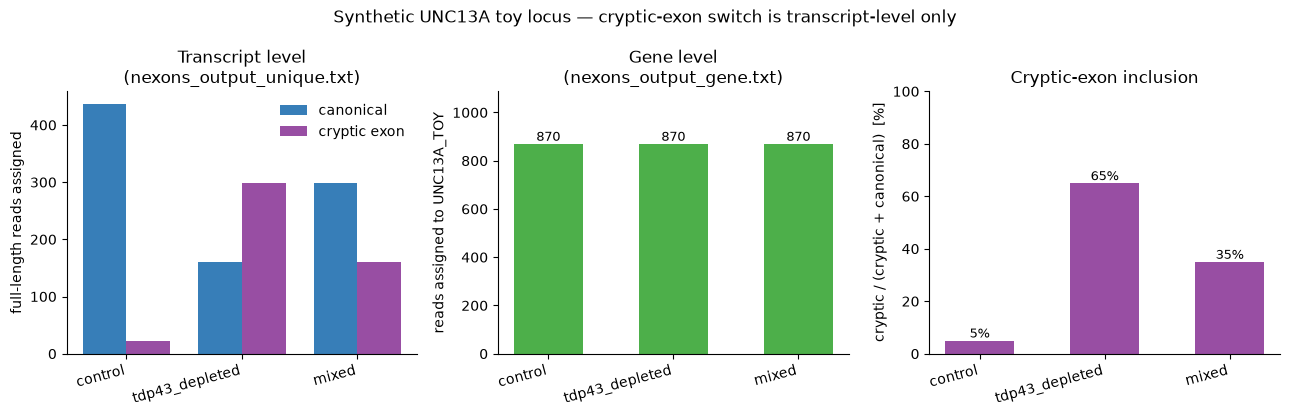

In [9]:
CANON_C, CRYPT_C, GENE_C = "#377eb8", "#984ea3", "#4daf4a"

u = unique1.set_index("Transcript_ID")
canon = u.loc["UNC13A_TOY-CANONICAL", SAMPLES].astype(float).values
cryp = u.loc["UNC13A_TOY-CRYPTIC", SAMPLES].astype(float).values
gene = gene1.set_index("Gene_ID").loc["UNC13A_TOY", SAMPLES].astype(float).values
labels = [s.replace(".bam", "") for s in SAMPLES]
x = range(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

ax = axes[0]
w = 0.38
ax.bar([i - w / 2 for i in x], canon, w, label="canonical", color=CANON_C)
ax.bar([i + w / 2 for i in x], cryp, w, label="cryptic exon", color=CRYPT_C)
ax.set_title("Transcript level\n(nexons_output_unique.txt)")
ax.set_ylabel("full-length reads assigned")
ax.legend(frameon=False)

ax = axes[1]
ax.bar(list(x), gene, 0.55, color=GENE_C)
ax.set_title("Gene level\n(nexons_output_gene.txt)")
ax.set_ylabel("reads assigned to UNC13A_TOY")
ax.set_ylim(0, max(gene) * 1.25)
for i, v in zip(x, gene):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
ax.bar(list(x), incl.values * 100, 0.55, color=CRYPT_C)
ax.set_title("Cryptic-exon inclusion")
ax.set_ylabel("cryptic / (cryptic + canonical)  [%]")
ax.set_ylim(0, 100)
for i, v in zip(x, incl.values * 100):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Synthetic UNC13A toy locus — cryptic-exon switch is transcript-level only",
             fontsize=12)
fig.tight_layout()
fig.savefig(DATA_OUTPUT / "cryptic_exon_switch.png", dpi=150)
plt.show()

**Read the middle panel.** The gene-level count is *identical* across the three
samples: every read still comes from `UNC13A_TOY`, so a gene-level counter —
which is what a short-read RNA-seq pipeline reports by default — sees no
change at all. The left and right panels are the same reads split by isoform,
and there the switch from canonical to cryptic is unmistakable. That
gene-level-invisible / transcript-level-obvious contrast is the reason
long-read quantitation is used for cryptic-exon work in ALS.

## 6. QC reports — what makes examples 1, 2 and 3 differ

nexons writes one HTML QC report per BAM plus a machine-readable
`*_stats.txt` (JSON). The two doughnut charts we are targeting are:

- **Alignment Fate** — nested rings, one per assignment class. The
  *purple* ring is `Multi Gene Match`.
- **Alignment Directionality** — red = same strand as the gene,
  *blue* = opposite strand.

In [10]:
def outcomes(results: Path) -> pd.DataFrame:
    rows = []
    for f in sorted(results.glob("*_stats.txt")):
        o = json.loads(f.read_text())["outcomes"]
        strand_total = o["Same_Strand_Hit"] + o["Opposing_Strand_Hit"]
        rows.append({
            "bam": json.loads(f.read_text())["file"],
            "total_reads": o["Total_Reads"],
            "primary": o["Primary_Alignment"],
            "unique": o["Unique"],
            "partial": o["Partial"],
            "gene": o["Gene"],
            "multi_gene": o["Multi_Gene"],
            "pct_multi_gene": 100 * o["Multi_Gene"] / o["Primary_Alignment"],
            "pct_opposite_strand": 100 * o["Opposing_Strand_Hit"] / strand_total,
        })
    return pd.DataFrame(rows)

qc = pd.concat({f"example{ex}": outcomes(r) for ex, r in RESULTS.items()},
               names=["example"]).reset_index(level=0)
qc.to_csv(DATA_OUTPUT / "qc_summary.csv", index=False)

pd.set_option("display.width", 160)
print(qc.round(1).to_string(index=False))

 example                bam  total_reads  primary  unique  partial  gene  multi_gene  pct_multi_gene  pct_opposite_strand
example1        control.bam         1000      900     460      650   870           0             0.0                  0.0
example1          mixed.bam         1000      900     460      650   870           0             0.0                  0.0
example1 tdp43_depleted.bam         1000      900     460      650   870           0             0.0                  0.0
example2        control.bam          970      900     350      450   450         450            50.0                  0.0
example2          mixed.bam          970      900     350      450   450         450            50.0                  0.0
example2 tdp43_depleted.bam          970      900     350      450   450         450            50.0                  0.0
example3        control.bam         1000      900     460      650   870           0             0.0                 33.3
example3          mixed.

Expected signatures — `example2` pushes half of all primary alignments into
`Multi Gene Match` (purple), and `example3` puts a third of all assigned reads
on the opposite strand (blue), while `example1` has neither.

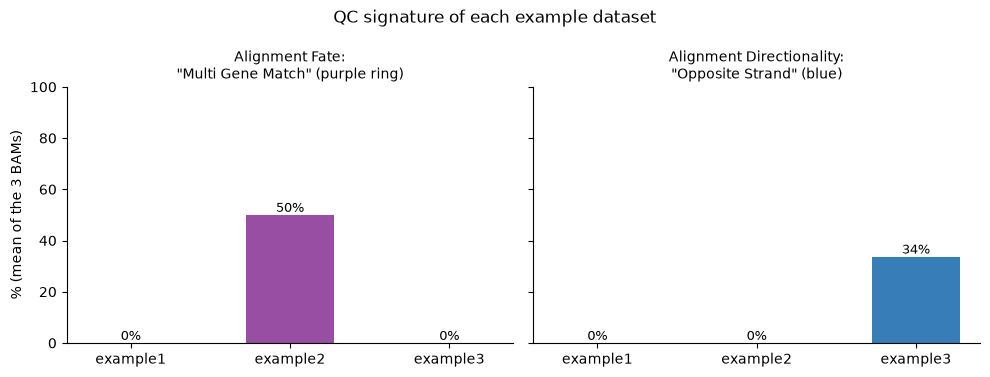

In [12]:
MULTI_C, OPP_C = "#984ea3", "#377eb8"
agg = qc.groupby("example")[["pct_multi_gene", "pct_opposite_strand"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (col, colour, title) in zip(axes, [
    ("pct_multi_gene", MULTI_C, 'Alignment Fate:\n"Multi Gene Match" (purple ring)'),
    ("pct_opposite_strand", OPP_C, 'Alignment Directionality:\n"Opposite Strand" (blue)'),
]):
    ax.bar(agg.index, agg[col], 0.55, color=colour)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
    for i, v in enumerate(agg[col]):
        ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("% (mean of the 3 BAMs)")

fig.suptitle("QC signature of each example dataset", fontsize=12)
fig.tight_layout()
fig.savefig(DATA_OUTPUT / "qc_signatures.png", dpi=150)
plt.show()

### Why each example looks the way it does

- **`example1`** — reads either match a whole transcript, match one transcript
  partially, or are fragments/intron-retaining reads that only resolve to the
  gene. One gene is annotated, so `Multi Gene Match` cannot occur; every read
  is on the gene's own strand, so directionality is 100 % same-strand. This is
  the shape a clean, correctly stranded library should give.
- **`example2`** — the GTF also contains `UNC13A_TOY_PARALOG`, which shares
  exons 2–20 with the main gene but has neither exon 1 nor exon 21. Full-length
  reads therefore still resolve uniquely, but short internal fragments are
  compatible with a transcript in *both* genes and nexons refuses to assign
  them: they become `Multi Gene Match`. In real data this is what a recently
  duplicated gene family, or an over-fragmented library, looks like — the
  purple ring is a warning that a large share of your reads are being
  discarded from all transcript- and gene-level tables.
- **`example3`** — a third of the reads are aligned antisense to the gene. With
  `--direction none` (the default) nexons still counts them, but flags them in
  the directionality chart. A large blue fraction in real data means the
  library is not as stranded as assumed, or that antisense transcription is
  being captured; either way the strand-agnostic counts should not be trusted
  without checking.

> **One quirk worth knowing.** In the directionality totals nexons counts a
> full-length (`unique`) read twice, so `Same + Opposite` exceeds
> `Primary Alignment`. The *ratio* is unaffected, which is what the chart
> shows, but do not read the raw numbers as a read count.

## 7. Open the QC reports

In [13]:
for ex, r in RESULTS.items():
    print(f"example{ex}:")
    for h in sorted(r.glob("*_qc.html")):
        print("   ", h.relative_to(SANDBOX))

example1:
    data/input/example1/results/nexons_output_control_qc.html
    data/input/example1/results/nexons_output_mixed_qc.html
    data/input/example1/results/nexons_output_tdp43_depleted_qc.html
example2:
    data/input/example2/results/nexons_output_control_qc.html
    data/input/example2/results/nexons_output_mixed_qc.html
    data/input/example2/results/nexons_output_tdp43_depleted_qc.html
example3:
    data/input/example3/results/nexons_output_control_qc.html
    data/input/example3/results/nexons_output_mixed_qc.html
    data/input/example3/results/nexons_output_tdp43_depleted_qc.html


Open any of those in a browser (in JupyterLab: right-click the file in the file
browser → *Open in New Browser Tab*) to see the Read Fate, Alignment Fate,
Alignment Directionality, read-length, transcript-coverage and splice-site
flexibility charts for that BAM.

### Files produced

```
sandbox/
├── data/
│   ├── make_dummy_data.py
│   ├── input/                              # generated dummy datasets
│   │   ├── example1/  unc13a_toy.gtf, {control,tdp43_depleted,mixed}.bam(.bai)
│   │   │   └── results/  nexons_output_{unique,partial,gene}.txt
│   │   │                 nexons_output_<sample>_qc.html
│   │   │                 nexons_output_<sample>_stats.txt
│   │   ├── example2/  ... (GTF additionally contains UNC13A_TOY_PARALOG)
│   │   └── example3/  ...
│   └── output/                             # produced by this notebook
│       ├── cryptic_exon_switch.png
│       ├── qc_signatures.png
│       └── qc_summary.csv
└── notebooks/
    └── nexons_als_demo.ipynb
```
